# 🏭 MLOps Jenkins Shared Library – End-to-End Colab Notebook
## Industrial Machine Efficiency Prediction Pipeline
---
**Project Structure (mirrors the Jenkins Shared Library CI/CD project):**
```
PROJECT/
├── src/
│   ├── logger.py
│   ├── custom_exception.py
│   ├── data_processing.py
│   └── model_training.py
├── pipeline/
│   └── training_pipeline.py
├── artifacts/
│   ├── raw/
│   ├── processed/
│   └── models/
├── k8s/
│   ├── deployment.yaml
│   └── service.yaml
├── application.py
├── Jenkinsfile
├── requirements.txt
└── setup.py
```
---
### 🔑 Required API Keys / Secrets (Colab → Runtime → Manage Secrets)
| Secret Name | Purpose |
|---|---|
| `GROQ_API_KEY` | Groq LLM (`llama-3.1-8b-instant`) for AI feature analysis |
| `MONGO_DB_URL` | MongoDB Atlas connection string |
| `MLFLOW_TRACKING_URI` | DagsHub / MLflow tracking server URL |
| `MLFLOW_TRACKING_USERNAME` | DagsHub username |
| `MLFLOW_TRACKING_PASSWORD` | DagsHub access token / password |
| `GITHUB_TOKEN` | GitHub PAT for auto-push (optional) |


## ⚙️ Phase 0 – Environment Setup & Secret Configuration

In [12]:
# ─── Phase 0a: Install all required packages ─────────────────────────────
# mlflow       → experiment tracking (DagsHub)
# pymongo      → MongoDB Atlas client
# groq          → Groq LLM client
# langchain-groq / langchain-core → LangChain ≥ 1.2 integration
!pip install -q -r requirements.txt
print('✅ All packages installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.

In [3]:
# ─── Phase 0b: Set Environment Variables from Colab Secrets ──────────────
# All credentials are pulled from Colab Secrets (Runtime → Manage Secrets).
# Never hard-code API keys in a notebook that will be committed to Git.

import os
from google.colab import userdata

# ── MongoDB ───────────────────────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── Groq ──────────────────────────────────────────────────────────────────
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ updated

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside Colab runtime
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


In [4]:
# ─── Phase 0c: Create Project Directory Structure ─────────────────────────
# Mirrors the exact layout of the Jenkins PROJECT repo so all
# downstream .py files use consistent relative paths.

import os

DIRS = [
    'src', 'pipeline',
    'artifacts/raw', 'artifacts/processed', 'artifacts/models',
    'logs', 'k8s', 'templates', 'static'
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)

print('✅ Project directories created:')
for d in DIRS:
    print(f'   ./{d}/')

✅ Project directories created:
   ./src/
   ./pipeline/
   ./artifacts/raw/
   ./artifacts/processed/
   ./artifacts/models/
   ./logs/
   ./k8s/
   ./templates/
   ./static/


## 📦 Phase 1 – Write Source Module Files to Disk
> All `.py` files mirror the original project's `src/` and `pipeline/` layout.
> Each file is saved so that imports work correctly and Git push in Phase 8 captures them.

In [5]:
# ─── Phase 1a: src/__init__.py & src/logger.py ───────────────────────────
# logger.py: creates a dated log file under ./logs/ and streams to console.
# Every module calls get_logger(__name__) to get a named logger instance.

with open('src/__init__.py', 'w') as f:
    f.write('# src package\n')

logger_code = '''
import logging
import os
from datetime import datetime

LOGS_DIR = "logs"
os.makedirs(LOGS_DIR, exist_ok=True)
LOG_FILE = os.path.join(LOGS_DIR, f"log_{datetime.now().strftime('%Y-%m-%d')}.log")

logging.basicConfig(
    filename=LOG_FILE,
    format="%(asctime)s - %(levelname)s - %(message)s",
    level=logging.INFO
)

console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)
console_handler.setFormatter(
    logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")
)

def get_logger(name):
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    if not logger.handlers:
        logger.addHandler(console_handler)
    return logger
'''
with open('src/logger.py', 'w') as f:
    f.write(logger_code.strip())

print('✅ src/__init__.py written')
print('✅ src/logger.py written')

✅ src/__init__.py written
✅ src/logger.py written


In [6]:
# ─── Phase 1b: src/custom_exception.py ──────────────────────────────────
# Wraps Python exceptions with file name + line number for easy debugging.
# All pipeline classes raise CustomException on errors.

exc_code = '''
import sys

class CustomException(Exception):
    def __init__(self, message: str, error_detail: Exception = None):
        self.error_message = self.get_detailed_error_message(message, error_detail)
        super().__init__(self.error_message)

    @staticmethod
    def get_detailed_error_message(message, error_detail):
        """Format the error message with file name and line number."""
        _, _, exc_tb = sys.exc_info()
        file_name   = exc_tb.tb_frame.f_code.co_filename if exc_tb else "Unknown"
        line_number = exc_tb.tb_lineno if exc_tb else "Unknown"
        return (
            f"{message} | Error: {error_detail}"
            f" | File: {file_name} | Line: {line_number}"
        )

    def __str__(self):
        return self.error_message
'''
with open('src/custom_exception.py', 'w') as f:
    f.write(exc_code.strip())

print('✅ src/custom_exception.py written')

✅ src/custom_exception.py written


In [27]:
# ─── Phase 1c: src/data_processing.py ───────────────────────────────────
# DataProcessing class – exact mirror of original src/data_processing.py
# Steps:
#   1. load_data()               → reads raw CSV from artifacts/raw/data.csv
#   2. preprocess()              → parses Timestamp, label-encodes categoricals
#   3. split_and_scale_and_save()→ StandardScaler, 80/20 split, saves .pkl files
# Output: X_train, X_test, y_train, y_test, scaler (all as .pkl)

dp_code = '''
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from src.logger import get_logger
from src.custom_exception import CustomException

logger = get_logger(__name__)

class DataProcessing:
    def __init__(self, input_path, output_path):
        self.input_path  = input_path
        self.output_path = output_path
        self.df          = None
        self.features    = None
        os.makedirs(self.output_path, exist_ok=True)
        logger.info("DataProcessing initialized.")

    def load_data(self):
        try:
            self.df = pd.read_csv(self.input_path)
            logger.info(f"Data loaded: {self.df.shape[0]} rows, {self.df.shape[1]} cols")
        except Exception as e:
            logger.error(f"Error loading data: {e}")
            raise CustomException("Failed to load data", e)

    def preprocess(self):
        try:
            # Drop rows with NaN in target variable before further processing
            initial_rows = self.df.shape[0]
            self.df.dropna(subset=['Efficiency_Status'], inplace=True)
            if self.df.shape[0] < initial_rows:
                logger.warning(f"Dropped {initial_rows - self.df.shape[0]} rows with NaN in 'Efficiency_Status'.")

            self.df["Timestamp"] = pd.to_datetime(self.df["Timestamp"], errors="coerce")
            self.df["Year"]  = self.df["Timestamp"].dt.year
            self.df["Month"] = self.df["Timestamp"].dt.month
            self.df["Day"]   = self.df["Timestamp"].dt.day
            self.df["Hour"]  = self.df["Timestamp"].dt.hour
            self.df.drop(columns=["Timestamp", "Machine_ID"], inplace=True)
            for col in ["Efficiency_Status", "Operation_Mode"]:
                le = LabelEncoder()
                self.df[col] = le.fit_transform(self.df[col])
            logger.info("Preprocessing complete.")
        except Exception as e:
            logger.error(f"Error preprocessing: {e}")
            raise CustomException("Failed to preprocess data", e)

    def split_and_scale_and_save(self):
        try:
            self.features = [
                "Operation_Mode", "Temperature_C", "Vibration_Hz",
                "Power_Consumption_kW", "Network_Latency_ms", "Packet_Loss_%",
                "Quality_Control_Defect_Rate_%", "Production_Speed_units_per_hr",
                "Predictive_Maintenance_Score", "Error_Rate_%",
                "Year", "Month", "Day", "Hour"
            ]
            X = self.df[self.features]
            y = self.df["Efficiency_Status"]
            # Debug print to check value counts of y before splitting
            print(f"DEBUG: Value counts for y before train_test_split:\n{y.value_counts()}")
            scaler   = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            X_train, X_test, y_train, y_test = train_test_split(
                X_scaled, y, test_size=0.2, random_state=42, stratify=y
            )
            for name, obj in [("X_train", X_train), ("X_test", X_test),
                               ("y_train", y_train), ("y_test", y_test),
                               ("scaler", scaler)]:
                joblib.dump(obj, os.path.join(self.output_path, f"{name}.pkl"))
            logger.info("Train/test splits and scaler saved.")
        except Exception as e:
            logger.error(f"Error in split_and_scale_and_save: {e}")
            raise CustomException("Failed to split/scale/save data", e)

    def run(self):
        self.load_data()
        self.preprocess()
        self.split_and_scale_and_save()

if __name__ == "__main__":
    DataProcessing("artifacts/raw/data.csv", "artifacts/processed").run()
'''
with open('src/data_processing.py', 'w') as f:
    f.write(dp_code.strip())

print('✅ src/data_processing.py written')

✅ src/data_processing.py written


In [28]:
# ─── Phase 1d: src/model_training.py ────────────────────────────────────
# ModelTraining class with full MLflow experiment tracking.
# Steps:
#   1. load_data()      → loads processed .pkl splits
#   2. train_model()    → LogisticRegression(max_iter=1000), saves model.pkl
#   3. evaluate_model() → accuracy, precision, recall, F1 (weighted)
#   4. log_to_mlflow()  → logs params, metrics, and sklearn model to DagsHub

mt_code = '''
import os
import joblib
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from src.logger import get_logger
from src.custom_exception import CustomException

logger = get_logger(__name__)

class ModelTraining:
    def __init__(self, processed_data_path, model_output_path):
        self.processed_path = processed_data_path
        self.model_path     = model_output_path
        self.clf            = None
        self.metrics        = {}
        self.X_train = self.X_test = self.y_train = self.y_test = None
        os.makedirs(self.model_path, exist_ok=True)
        logger.info("ModelTraining initialized.")

    def load_data(self):
        try:
            self.X_train = joblib.load(os.path.join(self.processed_path, "X_train.pkl"))
            self.X_test  = joblib.load(os.path.join(self.processed_path, "X_test.pkl"))
            self.y_train = joblib.load(os.path.join(self.processed_path, "y_train.pkl"))
            self.y_test  = joblib.load(os.path.join(self.processed_path, "y_test.pkl"))
            logger.info(f"Train: {len(self.X_train)} | Test: {len(self.X_test)}")
        except Exception as e:
            raise CustomException("Failed to load processed data", e)

    def train_model(self):
        try:
            self.clf = LogisticRegression(random_state=42, max_iter=1000)
            self.clf.fit(self.X_train, self.y_train)
            joblib.dump(self.clf, os.path.join(self.model_path, "model.pkl"))
            logger.info("Model trained and saved.")
        except Exception as e:
            raise CustomException("Failed to train model", e)

    def evaluate_model(self):
        try:
            y_pred = self.clf.predict(self.X_test)
            self.metrics = {
                "accuracy":  round(accuracy_score(self.y_test, y_pred), 4),
                "precision": round(precision_score(self.y_test, y_pred, average="weighted"), 4),
                "recall":    round(recall_score(self.y_test, y_pred, average="weighted"), 4),
                "f1_score":  round(f1_score(self.y_test, y_pred, average="weighted"), 4),
            }
            for k, v in self.metrics.items():
                logger.info(f"  {k}: {v}")
            return self.metrics
        except Exception as e:
            raise CustomException("Failed to evaluate model", e)

    def log_to_mlflow(self):
        """Log params, metrics and model artifact to the configured MLflow backend."""
        try:
            mlflow.set_tracking_uri(os.environ.get("MLFLOW_TRACKING_URI", ""))
            mlflow.set_experiment("MLOps-Jenkins-SharedLib")
            with mlflow.start_run(run_name="LogisticRegression-Run"):
                mlflow.log_param("model_type",   "LogisticRegression")
                mlflow.log_param("max_iter",     1000)
                mlflow.log_param("random_state", 42)
                mlflow.log_param("test_size",    0.2)
                mlflow.log_param("stratify",     True)
                for k, v in self.metrics.items():
                    mlflow.log_metric(k, v)
                mlflow.sklearn.log_model(self.clf, "model")
            logger.info("MLflow logging complete.")
        except Exception as e:
            logger.warning(f"MLflow logging failed (non-fatal): {e}")

    def run(self):
        self.load_data()
        self.train_model()
        metrics = self.evaluate_model()
        self.log_to_mlflow()
        return metrics

if __name__ == "__main__":
    ModelTraining("artifacts/processed/", "artifacts/models/").run()
'''
with open('src/model_training.py', 'w') as f:
    f.write(mt_code.strip())

print('✅ src/model_training.py written')

✅ src/model_training.py written


In [29]:
# ─── Phase 1e: pipeline/training_pipeline.py ─────────────────────────────
# Orchestrator: calls DataProcessing then ModelTraining in sequence.
# Mirrors the original pipeline/training_pipeline.py exactly.

import os
os.makedirs('pipeline', exist_ok=True)

with open('pipeline/__init__.py', 'w') as f:
    f.write('')

pipeline_code = '''
from src.data_processing import DataProcessing
from src.model_training import ModelTraining

if __name__ == "__main__":
    # Step 1 – Process raw data
    processor = DataProcessing("artifacts/raw/data.csv", "artifacts/processed")
    processor.run()

    # Step 2 – Train and evaluate model
    trainer = ModelTraining("artifacts/processed/", "artifacts/models/")
    trainer.run()
'''
with open('pipeline/training_pipeline.py', 'w') as f:
    f.write(pipeline_code.strip())

print('✅ pipeline/__init__.py written')
print('✅ pipeline/training_pipeline.py written')

✅ pipeline/__init__.py written
✅ pipeline/training_pipeline.py written


In [30]:
# ─── Phase 1f: requirements.txt & setup.py ───────────────────────────────
# requirements.txt lists all pip dependencies for the project.
# setup.py uses find_packages() so src/ and pipeline/ are importable.

req = """pandas
numpy
scikit-learn
flask
joblib
matplotlib
seaborn
mlflow
pymongo
dnspython
groq
langchain-groq
langchain-core
langchain
"""
with open('requirements.txt', 'w') as f:
    f.write(req)

setup = '''
from setuptools import setup, find_packages

with open("requirements.txt") as f:
    requirements = f.read().splitlines()

setup(
    name="MLOPS-PROJECT-9",
    version="0.1",
    author="Sudhanshu",
    packages=find_packages(),
    install_requires=requirements,
)
'''
with open('setup.py', 'w') as f:
    f.write(setup.strip())

print('✅ requirements.txt written')
print('✅ setup.py written')

✅ requirements.txt written
✅ setup.py written


## 📥 Phase 2 – Data Ingestion (MongoDB → Raw CSV)
> Pulls data from MongoDB Atlas and saves to `artifacts/raw/data.csv`.
> Falls back to an uploaded local CSV if MongoDB is unavailable.

In [31]:
# ─── Phase 2: MongoDB Data Ingestion ────────────────────────────────────
# Connects to MongoDB Atlas using MONGO_DB_URL secret.
# Fetches all records from the machine_efficiency collection.
# Falls back to local /content/data.csv if Mongo is empty or unreachable.
#
# Data Schema (13 columns):
#   Timestamp, Machine_ID, Operation_Mode, Temperature_C, Vibration_Hz,
#   Power_Consumption_kW, Network_Latency_ms, Packet_Loss_%,
#   Quality_Control_Defect_Rate_%, Production_Speed_units_per_hr,
#   Predictive_Maintenance_Score, Error_Rate_%, Efficiency_Status

import os
import sys
import pandas as pd
sys.path.insert(0, '.')
from pymongo import MongoClient
from src.logger import get_logger

logger = get_logger('data_ingestion')

MONGO_URL  = os.environ.get('MONGO_DB_URL', '')
DB_NAME    = 'mlops_project'
COLLECTION = 'machine_efficiency'
RAW_PATH   = 'artifacts/raw/data.csv'
LOCAL_CSV  = '/content/data.csv'   # ← upload your data.csv here if needed

def ingest_from_mongodb():
    try:
        client  = MongoClient(MONGO_URL, serverSelectionTimeoutMS=5000)
        records = list(client[DB_NAME][COLLECTION].find({}, {'_id': 0}))
        if not records:
            raise ValueError('MongoDB collection is empty.')
        df = pd.DataFrame(records)
        df.to_csv(RAW_PATH, index=False)
        logger.info(f'Ingested {len(df)} records from MongoDB.')
        return df
    except Exception as e:
        logger.warning(f'MongoDB ingestion failed: {e} — falling back to local CSV.')
        if os.path.exists(LOCAL_CSV):
            df = pd.read_csv(LOCAL_CSV)
            df.to_csv(RAW_PATH, index=False)
            logger.info(f'Loaded {len(df)} rows from local CSV.')
            return df
        raise FileNotFoundError(
            'No data source available. Upload data.csv to /content/ '
            'or populate the MongoDB collection.'
        )

df_raw = ingest_from_mongodb()
print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

2026-05-08 04:12:45,053 - WARNING - MongoDB ingestion failed: MongoDB collection is empty. — falling back to local CSV.
2026-05-08 04:12:46,978 - INFO - Loaded 100000 rows from local CSV.
INFO:data_ingestion:Loaded 100000 rows from local CSV.


Dataset shape: (100000, 13)


,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


## 🔍 Phase 3 – Exploratory Data Analysis (EDA)

In [32]:
# ─── Phase 3a: Dataset Overview ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

df = pd.read_csv('artifacts/raw/data.csv')

print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
print(f'Nulls   :\n{df.isnull().sum()}')
print(f'\nTarget distribution:\n{df["Efficiency_Status"].value_counts()}')
df.describe()

DATASET OVERVIEW
Shape   : (100000, 13)
Columns : ['Timestamp', 'Machine_ID', 'Operation_Mode', 'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score', 'Error_Rate_%', 'Efficiency_Status']
Nulls   :
Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

Target distribution:
Efficiency_Status
Low       77825
Medium    19189
High       2986
Name: count, dtype: int64


,Machine_ID,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,60.041458,2.549959,5.745929,25.555620,2.493418,5.008806,275.916324,0.499385,7.504100
std,14.389439,17.323238,1.414127,2.451271,14.120758,1.443273,2.883666,130.096892,0.288814,4.335896
min,1.000000,30.000138,0.100011,1.500183,1.000025,0.000026,0.000449,50.000375,0.000003,0.000112
25%,13.000000,45.031596,1.323214,3.627318,13.355118,1.245026,2.521591,162.873618,0.248166,3.750148
50%,25.000000,60.033597,2.549441,5.755460,25.536079,2.487667,5.003569,276.648922,0.499209,7.504145
75%,38.000000,74.967217,3.776459,7.860267,37.796372,3.741252,7.506127,388.812761,0.748810,11.273189
max,50.000000,89.998979,4.999974,9.999889,49.999917,4.999975,9.999900,499.996768,0.999978,14.999869


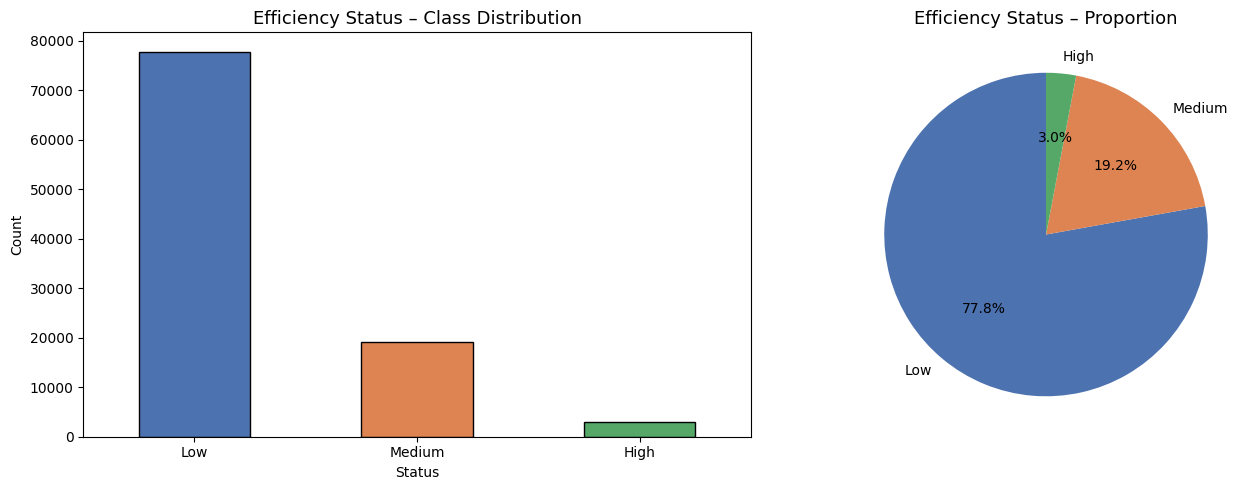

✅ Saved → artifacts/eda_class_distribution.png


In [33]:
# ─── Phase 3b: Target Class Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Efficiency_Status'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#4C72B0','#DD8452','#55A868'], edgecolor='black'
)
axes[0].set_title('Efficiency Status – Class Distribution', fontsize=13)
axes[0].set_xlabel('Status'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Efficiency_Status'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#4C72B0','#DD8452','#55A868'], startangle=90
)
axes[1].set_ylabel('')
axes[1].set_title('Efficiency Status – Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('artifacts/eda_class_distribution.png', dpi=100)
plt.show()
print('✅ Saved → artifacts/eda_class_distribution.png')

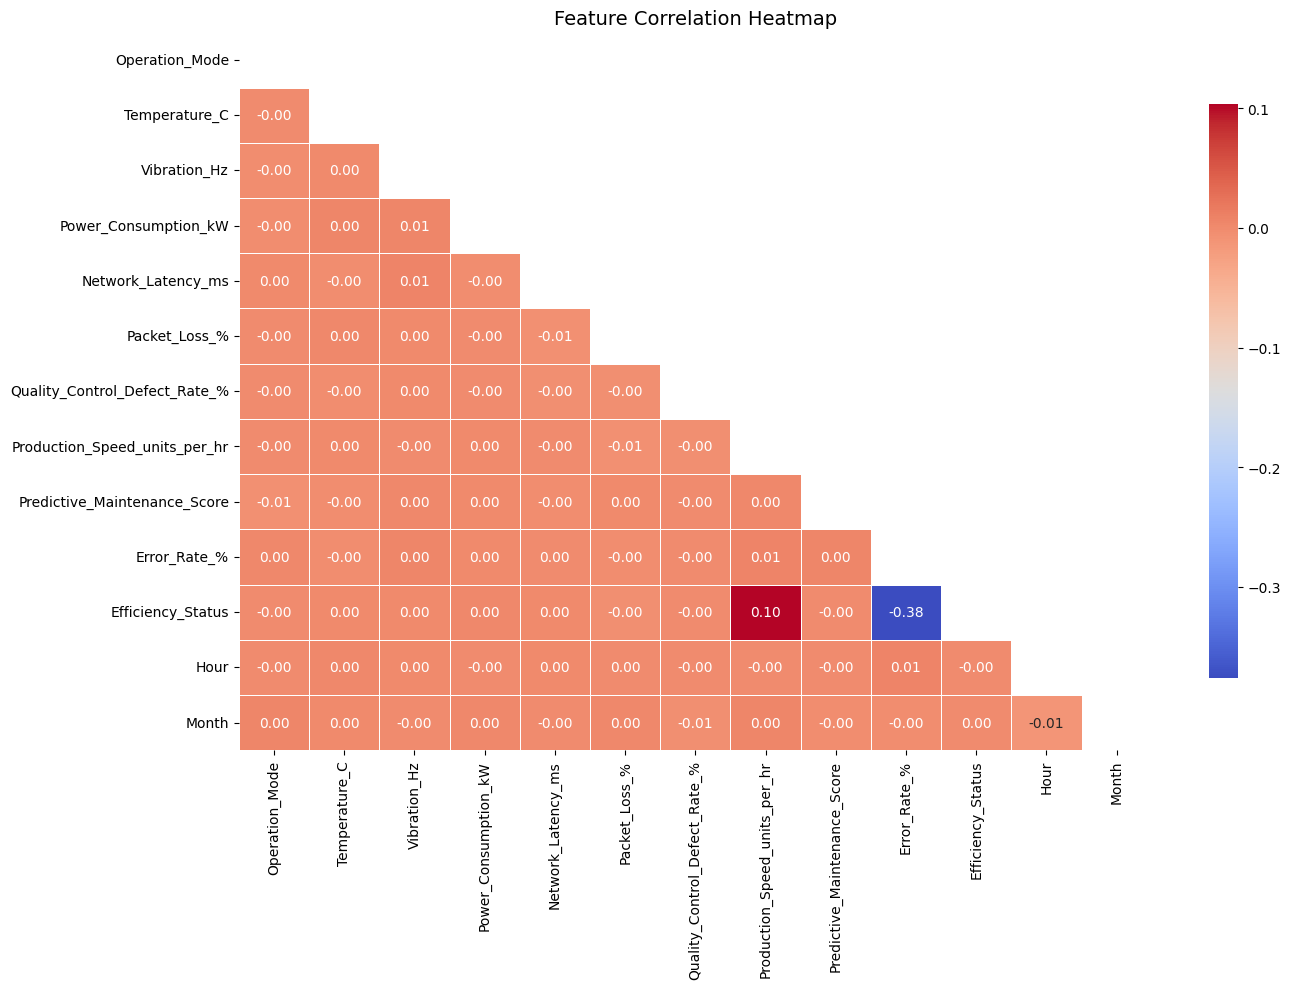

✅ Saved → artifacts/eda_correlation_heatmap.png


In [34]:
# ─── Phase 3c: Correlation Heatmap ──────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

df_eda = df.copy()
df_eda['Timestamp'] = pd.to_datetime(df_eda['Timestamp'], errors='coerce')
df_eda['Hour']  = df_eda['Timestamp'].dt.hour
df_eda['Month'] = df_eda['Timestamp'].dt.month
df_eda.drop(columns=['Timestamp','Machine_ID'], errors='ignore', inplace=True)
for col in ['Efficiency_Status','Operation_Mode']:
    df_eda[col] = LabelEncoder().fit_transform(df_eda[col])

numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr = df_eda[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('artifacts/eda_correlation_heatmap.png', dpi=100)
plt.show()
print('✅ Saved → artifacts/eda_correlation_heatmap.png')

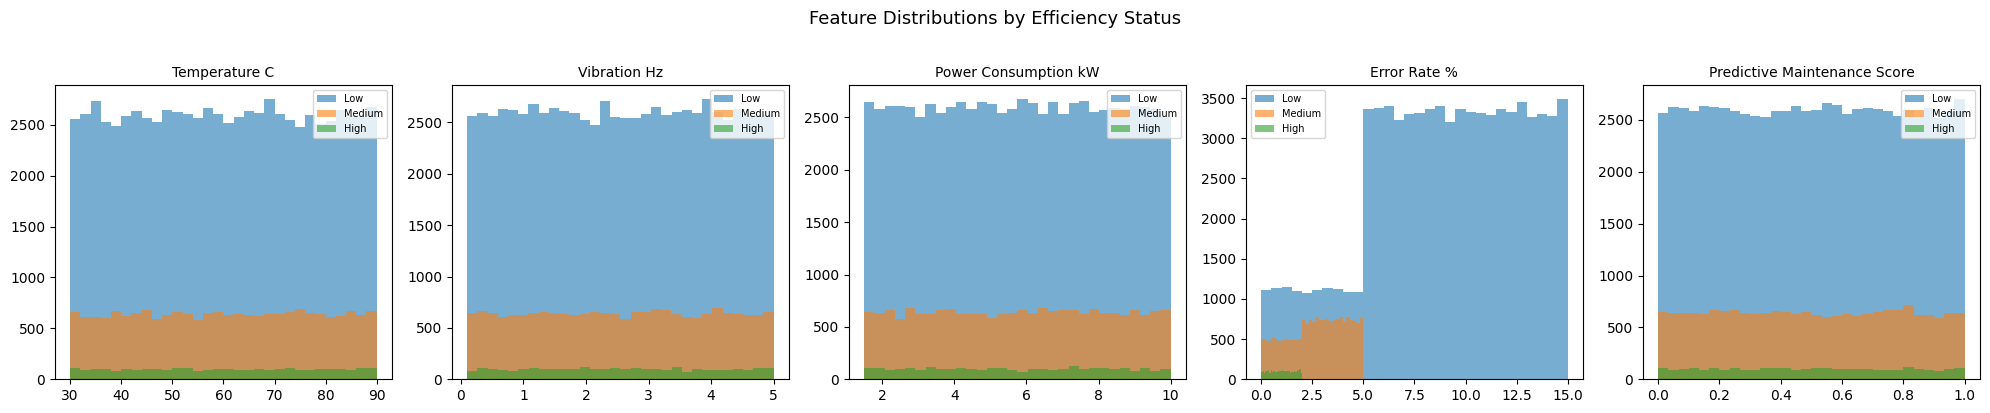

✅ Saved → artifacts/eda_feature_distributions.png


In [35]:
# ─── Phase 3d: Feature Distributions by Efficiency Status ────────────────
key_features = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Error_Rate_%', 'Predictive_Maintenance_Score'
]
fig, axes = plt.subplots(1, len(key_features), figsize=(20, 4))
for ax, feat in zip(axes, key_features):
    for status in df['Efficiency_Status'].unique():
        ax.hist(df[df['Efficiency_Status'] == status][feat],
                bins=30, alpha=0.6, label=status)
    ax.set_title(feat.replace('_', ' '), fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Feature Distributions by Efficiency Status', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('artifacts/eda_feature_distributions.png', dpi=100)
plt.show()
print('✅ Saved → artifacts/eda_feature_distributions.png')

## 🤖 Phase 4 – AI Feature Analysis via Groq LLM (LangChain ≥ 1.2)
> Uses `llama-3.1-8b-instant` on Groq to interpret feature correlations
> and generate domain-level insights for the MLOps report.
> `max_tokens=512` keeps within Groq free-tier rate limits.

In [36]:
# ─── Phase 4: Groq LLM Feature Insight via LangChain ────────────────────
# LangChain ≥ 1.2 (langchain-groq + langchain-core) is used here.
# The prompt summarises top correlations with the target and requests
# plain-English domain insights for the MLOps pipeline report.

import os, json
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage

# Build correlation summary with target variable
df_llm = pd.read_csv('artifacts/raw/data.csv')
df_llm['Timestamp'] = pd.to_datetime(df_llm['Timestamp'], errors='coerce')
df_llm['Hour']  = df_llm['Timestamp'].dt.hour
df_llm['Month'] = df_llm['Timestamp'].dt.month
df_llm.drop(columns=['Timestamp','Machine_ID'], errors='ignore', inplace=True)
for col in ['Efficiency_Status','Operation_Mode']:
    df_llm[col] = LabelEncoder().fit_transform(df_llm[col])

corr_with_target = (
    df_llm.corr()['Efficiency_Status']
    .drop('Efficiency_Status')
    .sort_values(key=abs, ascending=False)
    .head(6).round(3).to_dict()
)

# Initialise ChatGroq with lightweight model, limited tokens
llm = ChatGroq(
    model='llama-3.1-8b-instant',
    temperature=0.3,
    max_tokens=512,
    api_key=os.environ['GROQ_API_KEY'],
)

system_msg = SystemMessage(content=(
    'You are an expert industrial ML engineer specialising in predictive '
    'maintenance and machine efficiency. Be concise and actionable.'
))
user_prompt = (
    f'Dataset: Industrial machine sensor readings (100,000 rows).\n'
    f'Target: Efficiency_Status (Low/Medium/High).\n\n'
    f'Top feature correlations with target:\n{json.dumps(corr_with_target, indent=2)}\n\n'
    f'Tasks:\n'
    f'1. Identify the 3 most important features and explain WHY they predict efficiency.\n'
    f'2. Suggest one feature-engineering idea to improve model performance.\n'
    f'3. Flag any potential data quality concerns.\n'
    f'Keep the response under 280 words.'
)

print('Calling Groq LLM (llama-3.1-8b-instant)...')
response    = llm.invoke([system_msg, HumanMessage(content=user_prompt)])
llm_insight = response.content

print('\n' + '=' * 60)
print('🤖 GROQ LLM FEATURE INSIGHT')
print('=' * 60)
print(llm_insight)

with open('artifacts/llm_feature_insight.txt', 'w') as f:
    f.write(llm_insight)
print('\n✅ LLM insight saved → artifacts/llm_feature_insight.txt')

Calling Groq LLM (llama-3.1-8b-instant)...

🤖 GROQ LLM FEATURE INSIGHT
**Task 1: Identify top 3 features and explain their significance**

Based on the correlation analysis, the top 3 features are:

1. **Error_Rate_%**: A negative correlation (-0.376) indicates that higher error rates are associated with lower efficiency. This makes sense, as errors can lead to reduced productivity and increased downtime.
2. **Production_Speed_units_per_hr**: A positive correlation (0.103) suggests that higher production speeds are linked to higher efficiency. This is expected, as faster production rates typically result in higher productivity.
3. **Packet_Loss_%**: A negative correlation (-0.004) implies that packet loss is associated with lower efficiency. This might be due to communication delays or data loss, which can impact machine performance.

**Task 2: Feature-engineering idea**

Consider creating a new feature: **Error_Rate_Percentage_of_Production_Speed**. This feature combines the error rat

## 🔧 Phase 5 – Data Processing
> Runs `DataProcessing` class. Saves processed splits and scaler to `artifacts/processed/`.

In [37]:
# ─── Phase 5: Run DataProcessing Pipeline ───────────────────────────────
# Executes:
#   load_data()               → reads artifacts/raw/data.csv
#   preprocess()              → parse Timestamp, encode categoricals
#   split_and_scale_and_save()→ StandardScaler + 80/20 split → .pkl files

import sys, os, joblib
sys.path.insert(0, '.')
from src.data_processing import DataProcessing

processor = DataProcessing(
    input_path='artifacts/raw/data.csv',
    output_path='artifacts/processed'
)
processor.run()

# Verify artifacts were created
print('\nProcessed artifacts:')
for fname in ['X_train.pkl','X_test.pkl','y_train.pkl','y_test.pkl','scaler.pkl']:
    path = f'artifacts/processed/{fname}'
    size = os.path.getsize(path) // 1024
    print(f'  ✅ {path}  ({size} KB)')

X_train = joblib.load('artifacts/processed/X_train.pkl')
print(f'\nX_train shape: {X_train.shape}')

2026-05-08 04:13:09,914 - INFO - DataProcessing initialized.
INFO:src.data_processing:DataProcessing initialized.
2026-05-08 04:13:10,216 - INFO - Data loaded: 100000 rows, 13 cols
INFO:src.data_processing:Data loaded: 100000 rows, 13 cols
2026-05-08 04:13:10,312 - INFO - Preprocessing complete.
INFO:src.data_processing:Preprocessing complete.
2026-05-08 04:13:10,417 - INFO - Train/test splits and scaler saved.
INFO:src.data_processing:Train/test splits and scaler saved.



Processed artifacts:
  ✅ artifacts/processed/X_train.pkl  (8750 KB)
  ✅ artifacts/processed/X_test.pkl  (2187 KB)
  ✅ artifacts/processed/y_train.pkl  (2500 KB)
  ✅ artifacts/processed/y_test.pkl  (625 KB)
  ✅ artifacts/processed/scaler.pkl  (1 KB)

X_train shape: (80000, 14)


## 🏋️ Phase 6 – Model Training & MLflow Logging
> Trains `LogisticRegression`, logs metrics to DagsHub via MLflow.

In [38]:
# ─── Phase 6a: Run ModelTraining Pipeline ───────────────────────────────
# Executes:
#   load_data()      → loads .pkl splits
#   train_model()    → LogisticRegression(max_iter=1000)
#   evaluate_model() → accuracy, precision, recall, F1
#   log_to_mlflow()  → logs params + metrics + model to DagsHub

from src.model_training import ModelTraining

trainer = ModelTraining(
    processed_data_path='artifacts/processed/',
    model_output_path='artifacts/models/'
)
metrics = trainer.run()

print('\n' + '=' * 45)
print('📊 MODEL EVALUATION METRICS')
print('=' * 45)
for k, v in metrics.items():
    bar = '█' * int(v * 30)
    print(f'  {k:<12}: {v:.4f}  {bar}')

print('\n✅ model.pkl saved → artifacts/models/model.pkl')
print('✅ Metrics logged to MLflow / DagsHub')

2026-05-08 04:13:17,780 - INFO - ModelTraining initialized.
INFO:src.model_training:ModelTraining initialized.
2026-05-08 04:13:17,794 - INFO - Train: 80000 | Test: 20000
INFO:src.model_training:Train: 80000 | Test: 20000
2026-05-08 04:13:18,851 - INFO - Model trained and saved.
INFO:src.model_training:Model trained and saved.
2026-05-08 04:13:18,900 - INFO -   accuracy: 0.9165
INFO:src.model_training:  accuracy: 0.9165
2026-05-08 04:13:18,905 - INFO -   precision: 0.915
INFO:src.model_training:  precision: 0.915
2026-05-08 04:13:18,908 - INFO -   recall: 0.9165
INFO:src.model_training:  recall: 0.9165
2026-05-08 04:13:18,916 - INFO -   f1_score: 0.9156
INFO:src.model_training:  f1_score: 0.9156
2026/05/08 04:13:20 INFO mlflow.tracking.fluent: Experiment with name 'MLOps-Jenkins-SharedLib' does not exist. Creating a new experiment.
2026/05/08 04:13:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 04:13:31 WARNING mlflow.sklearn: Savin

🏃 View run LogisticRegression-Run at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/18/runs/057c54c9297b44b592adf4d2ae32b287
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/18

📊 MODEL EVALUATION METRICS
  accuracy    : 0.9165  ███████████████████████████
  precision   : 0.9150  ███████████████████████████
  recall      : 0.9165  ███████████████████████████
  f1_score    : 0.9156  ███████████████████████████

✅ model.pkl saved → artifacts/models/model.pkl
✅ Metrics logged to MLflow / DagsHub


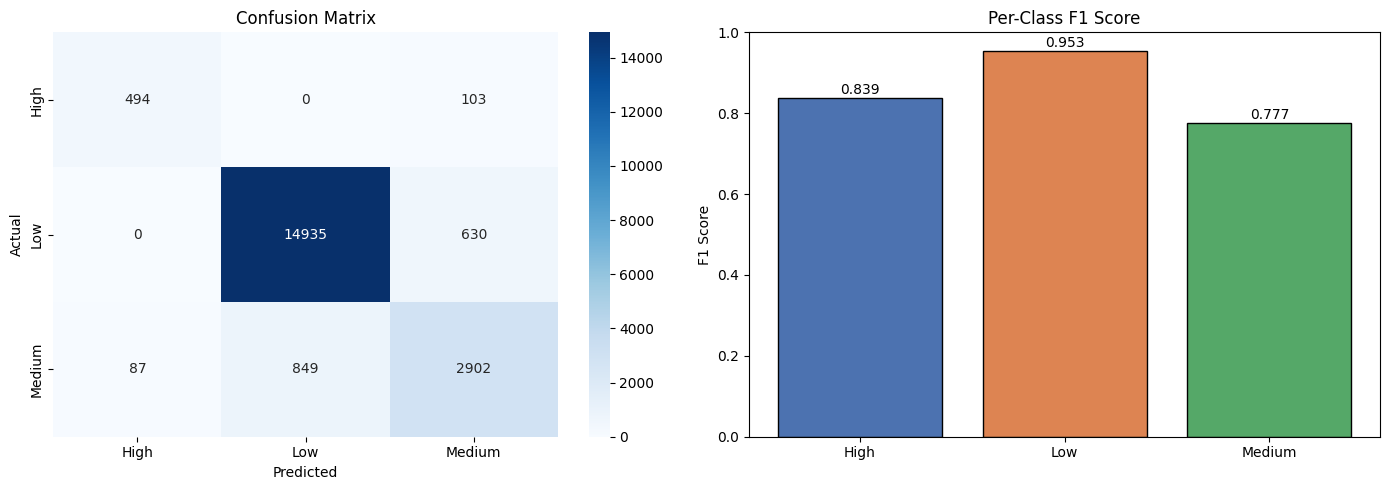

✅ Saved → artifacts/model_evaluation.png


In [39]:
# ─── Phase 6b: Confusion Matrix & Per-Class F1 ───────────────────────────
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model  = joblib.load('artifacts/models/model.pkl')
X_test = joblib.load('artifacts/processed/X_test.pkl')
y_test = joblib.load('artifacts/processed/y_test.pkl')
y_pred = model.predict(X_test)

# LabelEncoder uses alphabetical order → 0:High, 1:Low, 2:Medium
labels = ['High', 'Low', 'Medium']
cm     = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=labels, output_dict=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

f1_vals = [report[l]['f1-score'] for l in labels]
axes[1].bar(labels, f1_vals,
            color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')
axes[1].set_ylim(0, 1)
axes[1].set_title('Per-Class F1 Score')
axes[1].set_ylabel('F1 Score')
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('artifacts/model_evaluation.png', dpi=100)
plt.show()
print('✅ Saved → artifacts/model_evaluation.png')

## 🌐 Phase 7 – Write Flask App, Dockerfile & Kubernetes Manifests
> All infra files written to disk for Git push and Jenkins deployment.

In [40]:
# ─── Phase 7a: application.py (Flask Inference Server) ──────────────────
# GET  / → renders the prediction form
# POST / → receives 14 sensor features, returns Efficiency label
# NOTE: This runs on the deployed container, not in Colab directly.

app_code = '''
from flask import Flask, render_template, request
import joblib
import numpy as np

app = Flask(__name__)

model  = joblib.load("artifacts/models/model.pkl")
scaler = joblib.load("artifacts/processed/scaler.pkl")

FEATURES = [
    "Operation_Mode", "Temperature_C", "Vibration_Hz",
    "Power_Consumption_kW", "Network_Latency_ms", "Packet_Loss_%",
    "Quality_Control_Defect_Rate_%", "Production_Speed_units_per_hr",
    "Predictive_Maintenance_Score", "Error_Rate_%",
    "Year", "Month", "Day", "Hour"
]

LABELS = {0: "High", 1: "Low", 2: "Medium"}

@app.route("/", methods=["GET", "POST"])
def index():
    prediction = None
    if request.method == "POST":
        try:
            input_data = [float(request.form[f]) for f in FEATURES]
            scaled     = scaler.transform([input_data])
            pred       = model.predict(scaled)[0]
            prediction = LABELS.get(pred, "Unknown")
        except Exception as e:
            prediction = f"Error: {e}"
    return render_template("index.html", prediction=prediction, features=FEATURES)

if __name__ == "__main__":
    app.run(debug=True, host="0.0.0.0", port=5000)
'''
with open('application.py', 'w') as f:
    f.write(app_code.strip())
print('✅ application.py written')

✅ application.py written


In [41]:
# ─── Phase 7b: Dockerfile ────────────────────────────────────────────────
# Python 3.11 base image. Installs via setup.py, exposes port 5000.
# Docker stage is handled by the Jenkins Shared Library pipeline.

dockerfile = """FROM python:3.11
WORKDIR /app
COPY . /app
RUN pip install --no-cache-dir -e .
EXPOSE 5000
ENV FLASK_APP=application.py
CMD [\"python\", \"application.py\"]
"""
with open('Dockerfile', 'w') as f:
    f.write(dockerfile)
print('✅ Dockerfile written')

✅ Dockerfile written


In [42]:
# ─── Phase 7c: Kubernetes Manifests ─────────────────────────────────────
# deployment.yaml → 1 replica Flask container
# service.yaml    → NodePort 30007 exposes the app externally
# Update `image:` to your DockerHub repo before deploying.

import os
os.makedirs('k8s', exist_ok=True)

deployment_yaml = """apiVersion: apps/v1
kind: Deployment
metadata:
  name: flask-deployment
spec:
  replicas: 1
  selector:
    matchLabels:
      app: flask-app
  template:
    metadata:
      labels:
        app: flask-app
    spec:
      containers:
        - name: flask-container
          image: dataguru97/jenkins-shared-mlops-project:latest
          ports:
            - containerPort: 5000
"""
service_yaml = """apiVersion: v1
kind: Service
metadata:
  name: flask-service
spec:
  type: NodePort
  selector:
    app: flask-app
  ports:
    - protocol: TCP
      port: 80
      targetPort: 5000
      nodePort: 30007
"""
with open('k8s/deployment.yaml', 'w') as f:
    f.write(deployment_yaml)
with open('k8s/service.yaml', 'w') as f:
    f.write(service_yaml)
print('✅ k8s/deployment.yaml written')
print('✅ k8s/service.yaml written')

✅ k8s/deployment.yaml written
✅ k8s/service.yaml written


In [43]:
# ─── Phase 7d: Jenkinsfile (Docker stage excluded) ───────────────────────
# Uses @Library('jenkins-shared') shared library.
# Stages: Checkout → Install Kubectl → Deploy to Kubernetes
# Git repo points to: https://github.com/Prithu-Sarkar/GEN-AI-INDUSTRY-PROJECT_2.git

jenkinsfile = """@Library('jenkins-shared') _

pipeline {
    agent any

    stages {
        stage('Checkout') {
            steps {
                gitCheckout(
                    'https://github.com/Prithu-Sarkar/GEN-AI-INDUSTRY-PROJECT_2.git',
                    '*/main',
                    'github-token'
                )
            }
        }

        stage('Install Kubectl') {
            steps {
                installKubectl()
            }
        }

        stage('Deploy to Kubernetes') {
            steps {
                k8sDeploy('kubeconfig')
            }
        }
    }
}
"""
with open('Jenkinsfile', 'w') as f:
    f.write(jenkinsfile)
print('✅ Jenkinsfile written (Docker stage excluded)')

✅ Jenkinsfile written (Docker stage excluded)


## 🚀 Phase 8 – Push to GitHub (CI/CD Trigger)
> Commits all source files (excluding binaries) and pushes to your repo.
> Requires `GITHUB_TOKEN` in Colab Secrets.

In [44]:
# ─── Phase 8: Git Init, Commit & Push ───────────────────────────────────
# Writes .gitignore to exclude:
#   - Large binary artifacts (*.pkl, data.csv)
#   - Notebook outputs / execution state (*.ipynb, .ipynb_checkpoints/)
#   - Log files
# This keeps the repo clean and prevents notebook widget/state metadata
# from appearing after a Git push.

import os
from google.colab import userdata

GIT_REPO  = 'https://github.com/Prithu-Sarkar/GEN-AI-INDUSTRY-PROJECT_2.git'
GIT_USER  = 'Prithu-Sarkar'
GIT_EMAIL = 'prithu@example.com'   # ← update to your email

try:
    GIT_TOKEN = userdata.get('GITHUB_TOKEN')
except Exception:
    GIT_TOKEN = ''
    print('⚠️  GITHUB_TOKEN not found. Git push will be skipped.')

gitignore_content = """# Python
__pycache__/
*.pyc
*.pyo

# Artifacts (large binaries — tracked outside Git)
artifacts/raw/
artifacts/processed/
artifacts/models/
logs/
*.pkl
*.png

# Jupyter / Colab — never commit execution state or widget metadata
.ipynb_checkpoints/
*.ipynb

# OS
.DS_Store
Thumbs.db
"""
with open('.gitignore', 'w') as f:
    f.write(gitignore_content)
print('✅ .gitignore written')

if GIT_TOKEN:
    repo_url = GIT_REPO.replace('https://', f'https://{GIT_USER}:{GIT_TOKEN}@')
    !git config --global user.email "{GIT_EMAIL}"
    !git config --global user.name  "{GIT_USER}"
    if not os.path.exists('.git'):
        !git init
        !git remote add origin {repo_url}
    else:
        !git remote set-url origin {repo_url}
    !git add src/ pipeline/ k8s/ application.py Dockerfile Jenkinsfile \\
              requirements.txt setup.py .gitignore
    !git commit -m 'feat: MLOps Colab pipeline — data, training, Flask, k8s'
    !git push -u origin main --force
    print('✅ Code pushed to GitHub →', GIT_REPO)
else:
    print('Git push skipped. Add GITHUB_TOKEN to Colab Secrets to enable.')

✅ .gitignore written
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
fatal: pathspec ' ' did not match any files
On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	.gitignore
	Dockerfile
	Jenkinsfile
	application.py
	artifacts/
	data.csv
	k8s/
	pipeline/
	requirements.txt
	sample_data/
	setup.py
	src/

nothing added to commit but untracked files present (use "git add" to track)
error: src refspec main does not match any
error: faile

## 📦 Phase 9 – Package All Outputs & Download ZIP

In [45]:
# ─── Phase 9a: Bundle All Outputs into ZIP ───────────────────────────────
# Collects: source .py files, infra files, processed artifacts,
# EDA charts, model evaluation chart, LLM insight, k8s manifests, logs.

import zipfile, os

OUTPUT_ZIP = '/content/mlops_colab_outputs.zip'

INCLUDE = [
    'src/logger.py', 'src/custom_exception.py',
    'src/data_processing.py', 'src/model_training.py', 'src/__init__.py',
    'pipeline/training_pipeline.py', 'pipeline/__init__.py',
    'application.py', 'Dockerfile', 'Jenkinsfile',
    'requirements.txt', 'setup.py', '.gitignore',
    'k8s/deployment.yaml', 'k8s/service.yaml',
    'artifacts/models/model.pkl',
    'artifacts/processed/scaler.pkl',
    'artifacts/eda_class_distribution.png',
    'artifacts/eda_correlation_heatmap.png',
    'artifacts/eda_feature_distributions.png',
    'artifacts/model_evaluation.png',
    'artifacts/llm_feature_insight.txt',
]

# Add any log files
if os.path.exists('logs'):
    for fname in os.listdir('logs'):
        INCLUDE.append(os.path.join('logs', fname))

with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fpath in INCLUDE:
        if os.path.isfile(fpath):
            zf.write(fpath)
            print(f'  + {fpath}')
        else:
            print(f'  ⚠️  Skipped (not found): {fpath}')

size_kb = os.path.getsize(OUTPUT_ZIP) // 1024
print(f'\n✅ ZIP created: {OUTPUT_ZIP}  ({size_kb} KB)')

  + src/logger.py
  + src/custom_exception.py
  + src/data_processing.py
  + src/model_training.py
  + src/__init__.py
  + pipeline/training_pipeline.py
  + pipeline/__init__.py
  + application.py
  + Dockerfile
  + Jenkinsfile
  + requirements.txt
  + setup.py
  + .gitignore
  + k8s/deployment.yaml
  + k8s/service.yaml
  + artifacts/models/model.pkl
  + artifacts/processed/scaler.pkl
  + artifacts/eda_class_distribution.png
  + artifacts/eda_correlation_heatmap.png
  + artifacts/eda_feature_distributions.png
  + artifacts/model_evaluation.png
  + artifacts/llm_feature_insight.txt

✅ ZIP created: /content/mlops_colab_outputs.zip  (202 KB)


In [46]:
# ─── Phase 9b: Download ZIP to Local Machine ─────────────────────────────
# Triggers a browser download. If running headlessly,
# retrieve the file from the Files panel on the left sidebar.

from google.colab import files
files.download('/content/mlops_colab_outputs.zip')
print('⬇️  Download initiated: mlops_colab_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download initiated: mlops_colab_outputs.zip


## ✅ Phase 10 – Project Summary & Required API Keys

### 🔑 All Required Secrets (Colab → Runtime → Manage Secrets)

| Secret Name | Required? | Purpose |
|---|---|---|
| `GROQ_API_KEY` | ✅ Yes | Groq LLM – `llama-3.1-8b-instant` for AI feature insights |
| `MONGO_DB_URL` | ✅ Yes | MongoDB Atlas connection string for data ingestion |
| `MLFLOW_TRACKING_URI` | ✅ Yes | DagsHub MLflow server URL |
| `MLFLOW_TRACKING_USERNAME` | ✅ Yes | DagsHub username |
| `MLFLOW_TRACKING_PASSWORD` | ✅ Yes | DagsHub access token |
| `GITHUB_TOKEN` | ⚠️ Optional | GitHub PAT for auto-push in Phase 8 |

---

### 📋 Pipeline Phases

| Phase | Description | Key Outputs |
|---|---|---|
| 0 | Install packages, set secrets, create dirs | Environment ready |
| 1 | Write all `.py` source files to disk | `src/`, `pipeline/`, `application.py`, etc. |
| 2 | MongoDB ingestion → raw CSV | `artifacts/raw/data.csv` |
| 3 | EDA – distributions, heatmap | `artifacts/eda_*.png` |
| 4 | Groq LLM feature analysis | `artifacts/llm_feature_insight.txt` |
| 5 | DataProcessing – scale & split | `artifacts/processed/*.pkl` |
| 6 | ModelTraining + MLflow logging | `artifacts/models/model.pkl` |
| 7 | Flask app + Dockerfile + K8s manifests | `application.py`, `Dockerfile`, `k8s/` |
| 8 | Git commit & push → Jenkins CI/CD trigger | GitHub repo updated |
| 9 | ZIP & download all outputs | `mlops_colab_outputs.zip` |

---
> **Note:** Docker build and Kubernetes deployment are handled by the Jenkins
> Shared Library pipeline (`dockerBuildAndPush` + `k8sDeploy` Groovy vars)
> after the Git push in Phase 8 triggers the Jenkinsfile.
